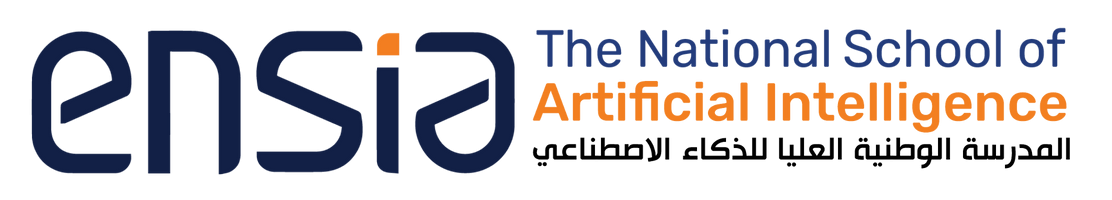

<div class="alert alert-block alert-warning">
<center>
    <h2>  The 3D Container Loading Optimizer </h2>
    <h4>A logic-based logistics tool that computes the optimal packing of 3D boxes into a standard shipping container to maximize volume utilization and stability, using Genetic Algorithms and Heuristic Search.</h4>
</center>
</div>

In [2]:
from __future__ import annotations

import heapq
import math
import random
import time
import json
from copy import deepcopy
from dataclasses import dataclass, field
from pathlib import Path
from typing import List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

sns.set_theme(style="whitegrid")
print("All imports OK ✅")

All imports OK ✅


<div class="alert alert-block alert-warning">
<center>
    <h2> Core Classes </h2></center>
</div>

Container, Box, Space, SpaceManager, CLOProblem (container loading optimization problem)

In [3]:
@dataclass
class Box:
    """Represents a single box to be packed."""
    id: int
    length: float   # X dimension
    width: float    # Z dimension  (depth)
    height: float   # Y dimension  (vertical)
    weight_kg: float = 0.0
    fragile: bool = False

    @property
    def volume(self) -> float:
        return self.length * self.width * self.height

    def get_dimensions(self) -> Tuple[float, float, float]:
        return (self.length, self.width, self.height)

    def get_orientations(self) -> List[Tuple[float, float, float]]:
        """All valid (l, w, h) orientations respecting fragile constraint."""
        l, w, h = self.length, self.width, self.height
        if self.fragile:
            # height must stay as the vertical dimension — no tipping
            return list({(l, w, h), (w, l, h)})
        return list({
            (l, w, h), (l, h, w),
            (w, l, h), (w, h, l),
            (h, l, w), (h, w, l),
        })

    def __repr__(self):
        return (f"Box(id={self.id}, "
                f"{self.length}×{self.width}×{self.height}, "
                f"fragile={self.fragile})")

In [4]:
@dataclass
class Container:
    """Axis convention:  X=length, Z=width(depth), Y=height."""
    length: float   # X
    width: float    # Z
    height: float   # Y

    @property
    def volume(self) -> float:
        return self.length * self.width * self.height

    def get_dimensions(self) -> Tuple[float, float, float]:
        return (self.length, self.width, self.height)

    def __repr__(self):
        return f"Container({self.length}×{self.width}×{self.height} cm)"


In [5]:
@dataclass
class PlacedBox:
    """A box that has been successfully placed inside the container."""
    box: Box
    # Corner position (bottom-left-front)
    x: float   # along container length
    y: float   # along container height  (0 = floor)
    z: float   # along container width/depth
    # Actual dimensions used (after orientation selection)
    l: float   # size in X
    h: float   # size in Y
    w: float   # size in Z

    @property
    def volume(self) -> float:
        return self.l * self.h * self.w

    def overlaps(self, other: PlacedBox) -> bool:
        """True when two placed boxes share interior volume."""
        return not (
            self.x + self.l <= other.x or other.x + other.l <= self.x or
            self.y + self.h <= other.y or other.y + other.h <= self.y or
            self.z + self.w <= other.z or other.z + other.w <= self.z
        )

    def is_within(self, container: Container) -> bool:
        return (
            self.x >= 0 and self.x + self.l <= container.length and
            self.y >= 0 and self.y + self.h <= container.height and
            self.z >= 0 and self.z + self.w <= container.width
        )

    def __repr__(self):
        return (f"PlacedBox(id={self.box.id}, "
                f"pos=({self.x},{self.y},{self.z}), "
                f"dims={self.l}×{self.h}×{self.w})")

In [6]:

class Space:
    """
    A free rectangular region inside the container.

    Axis mapping (consistent with PlacedBox):
        x, l  →  container length  (X)
        y, h  →  container height  (Y, vertical)
        z, w  →  container width   (Z, depth)
    """

    def __init__(self, x: float, y: float, z: float,
                 l: float, h: float, w: float):
        self.x = x   # origin X
        self.y = y   # origin Y (floor level)
        self.z = z   # origin Z
        self.l = l   # extent in X
        self.h = h   # extent in Y (vertical)
        self.w = w   # extent in Z

    def volume(self) -> float:
        return self.l * self.h * self.w

    def try_fit(self, box: Box, strategy: str = "best"):
        """
        Try every valid orientation of *box* and return (True, (l,h,w)) for
        the orientation that fits best, or (False, None).

        strategy:
            "first"  — return the first fitting orientation (fast)
            "best"   — return the orientation that wastes the least space
        """
        best_dims  = None
        best_score = float("inf")

        for (bl, bw, bh) in box.get_orientations():
            # get_orientations returns (length, width, height) tuples;
            # map them to our space axes: l=X, h=Y(vert), w=Z
            for (sl, sh, sw) in _axis_permutations(bl, bw, bh):
                if sl <= self.l and sh <= self.h and sw <= self.w:
                    if strategy == "first":
                        return True, (sl, sh, sw)
                    score = (self.l - sl) + (self.h - sh) + (self.w - sw)
                    if score < best_score:
                        best_score = score
                        best_dims  = (sl, sh, sw)

        return (True, best_dims) if best_dims else (False, None)

    def split(self, l: float, h: float, w: float) -> List[Space]:
        """
        Guillotine split after placing a box of size (l, h, w) at the
        bottom-left-front corner of this space.

        Produces up to 3 non-overlapping sub-spaces:
            Right  — to the right  (+X) of the box
            Above  — directly above (+Y) the box footprint
            Behind — behind        (+Z) the box
        """
        new_spaces = []

        # Right of box (X remainder, full height & depth of space)
        if self.l - l > 0:
            new_spaces.append(Space(
                self.x + l, self.y, self.z,
                self.l - l, self.h, self.w
            ))

        # Above box (Y remainder, only over box footprint)
        if self.h - h > 0:
            new_spaces.append(Space(
                self.x, self.y + h, self.z,
                l, self.h - h, w
            ))

        # Behind box (Z remainder, box-width footprint, full Y of space)
        if self.w - w > 0:
            new_spaces.append(Space(
                self.x, self.y, self.z + w,
                l, self.h, self.w - w
            ))

        return new_spaces

    def __repr__(self):
        return (f"Space(pos=({self.x},{self.y},{self.z}) "
                f"size={self.l}×{self.h}×{self.w} "
                f"vol={self.volume():.0f})")


def _axis_permutations(bl: float, bw: float, bh: float
                       ) -> List[Tuple[float, float, float]]:
    """
    All distinct assignments of box dims (bl, bw, bh) onto space axes
    (l=X, h=Y, w=Z).  Returns list of (sl, sh, sw).
    """
    return list({
        (bl, bw, bh), (bl, bh, bw),
        (bw, bl, bh), (bw, bh, bl),
        (bh, bl, bw), (bh, bw, bl),
    })


In [7]:
class SpaceManager:
    """
    Tracks all free rectangular spaces inside the container and handles
    placement, guillotine splitting, and cleanup.
    """

    def __init__(self, container: Container):
        self.container = container
        self._reset_spaces()

    def _reset_spaces(self):
        c = self.container
        self.spaces: List[Space] = [Space(0, 0, 0, c.length, c.height, c.width)]
        self._packed_volume: float = 0.0

    def reset(self):
        """Reinitialise to an empty container (used between algorithm runs)."""
        self._reset_spaces()

    # ------------------------------------------------------------------
    # Core placement API
    # ------------------------------------------------------------------

    def find_placement(self, box: Box, strategy: str = "bottom"):
        """
        Find the best free space and orientation for *box*.

        strategy:
            "first"  — first space / orientation that fits
            "best"   — minimise leftover gap in chosen space
            "bottom" — lowest Y first (gravity), then left, then front
        Returns (space, dims) or (None, None).
        """
        best_space = None
        best_dims  = None
        best_score = None

        sorted_spaces = self._sorted_spaces(strategy)

        for space in sorted_spaces:
            fits, dims = space.try_fit(
                box,
                strategy="first" if strategy == "first" else "best"
            )
            if not fits:
                continue

            if strategy == "first":
                return space, dims

            sl, sh, sw = dims
            if strategy == "best":
                score = (space.l - sl) + (space.h - sh) + (space.w - sw)
            elif strategy == "bottom":
                # primary: lowest Y; secondary: leftmost X; tertiary: front Z
                score = (space.y * 1_000_000) + (space.x * 1_000) + space.z
            else:
                raise ValueError(f"Unknown strategy '{strategy}'")

            if best_score is None or score < best_score:
                best_score = score
                best_space = space
                best_dims  = dims

        return best_space, best_dims

    def place_box(self, box: Box, space: Space,
                  dims: Tuple[float, float, float]) -> Optional[PlacedBox]:
        """
        Place *box* in *space* using *dims* (l, h, w).
        Removes the space, adds sub-spaces from guillotine split,
        and returns a PlacedBox.  Returns None if space is gone.
        """
        if space not in self.spaces:
            return None

        l, h, w = dims
        placed = PlacedBox(
            box=box,
            x=space.x, y=space.y, z=space.z,
            l=l, h=h, w=w
        )

        self.spaces.remove(space)
        self.spaces.extend(space.split(l, h, w))
        self._clean_spaces()

        self._packed_volume += placed.volume
        return placed

    # ------------------------------------------------------------------
    # Volume helpers
    # ------------------------------------------------------------------

    @property
    def packed_volume(self) -> float:
        """Accumulated volume of successfully placed boxes."""
        return self._packed_volume

    def utilization(self) -> float:
        """Packing utilisation as a percentage."""
        cv = self.container.volume
        return (self._packed_volume / cv * 100.0) if cv else 0.0

    # ------------------------------------------------------------------
    # Internal helpers
    # ------------------------------------------------------------------

    def _sorted_spaces(self, strategy: str) -> List[Space]:
        if strategy == "bottom":
            return sorted(self.spaces, key=lambda s: (s.y, s.x, s.z))
        return self.spaces  # unsorted is fine for "first"/"best"

    def _clean_spaces(self):
        """Remove degenerate (zero-volume) and fully-dominated spaces."""
        valid = [s for s in self.spaces if s.l > 0 and s.h > 0 and s.w > 0]
        cleaned = []
        for s in valid:
            if not any(
                other is not s and self._contains(other, s)
                for other in valid
            ):
                cleaned.append(s)
        self.spaces = cleaned

    @staticmethod
    def _contains(a: Space, b: Space) -> bool:
        """True when space *a* fully contains space *b*."""
        return (
            a.x <= b.x and a.y <= b.y and a.z <= b.z and
            a.x + a.l >= b.x + b.l and
            a.y + a.h >= b.y + b.h and
            a.z + a.w >= b.z + b.w
        )

    def print_spaces(self):
        print(f"SpaceManager — {len(self.spaces)} free spaces "
              f"(container vol={self.container.volume:.0f}):")
        for s in sorted(self.spaces, key=lambda s: (s.y, s.x, s.z)):
            print(f"  {s}")


In [8]:
@dataclass
class PackingResult:
    """Stores the outcome of any packing algorithm."""
    algorithm: str
    container: Container
    placed_boxes: List[PlacedBox]
    packed_volume: float
    execution_time_ms: float

    def utilization(self) -> float:
        return (self.packed_volume / self.container.volume) * 100.0

    def to_json(self) -> dict:
        return {
            "algorithm": self.algorithm,
            "container": {
                "length": self.container.length,
                "width":  self.container.width,
                "height": self.container.height,
                "volume": self.container.volume,
            },
            "stats": {
                "boxes_placed":       len(self.placed_boxes),
                "packed_volume_cm3":  round(self.packed_volume, 2),
                "utilization_pct":    round(self.utilization(), 2),
                "execution_time_ms":  round(self.execution_time_ms, 2),
            },
            "placed_boxes": [
                {
                    "id": p.box.id,
                    "x": p.x, "y": p.y, "z": p.z,
                    "l": p.l, "h": p.h, "w": p.w,
                    "fragile": p.box.fragile,
                    "weight_kg": p.box.weight_kg,
                }
                for p in self.placed_boxes
            ],
        }

    def __repr__(self):
        return (f"PackingResult(algorithm={self.algorithm!r}, "
                f"utilization={self.utilization():.2f}%, "
                f"boxes={len(self.placed_boxes)}, "
                f"time={self.execution_time_ms:.1f}ms)")


In [9]:
@dataclass
class CLOProblem:
    """Container Loading Optimisation Problem instance."""
    container: Container
    seq_boxes: List[Box]

    def __post_init__(self):
        total_vol = 0.0
        for box in self.seq_boxes:
            total_vol += box.volume
            if not self._fits_in_container(box):
                raise ValueError(
                    f"Box {box} cannot fit in {self.container} "
                    f"in any orientation."
                )
        self._total_box_volume = total_vol
        if total_vol > self.container.volume:
            print(
                f"⚠️  Warning: total box volume ({total_vol:,.0f} cm³) "
                f"exceeds container volume ({self.container.volume:,.0f} cm³). "
                f"Not all boxes will fit."
            )

    def _fits_in_container(self, box: Box) -> bool:
        """True if at least one orientation of *box* fits in the container."""
        cd = sorted(self.container.get_dimensions())
        bd = sorted(box.get_dimensions())
        return all(bd[i] <= cd[i] for i in range(3))

    @property
    def total_box_volume(self) -> float:
        return self._total_box_volume

    @property
    def container_volume(self) -> float:
        return self.container.volume

    def get_difficulty(self) -> str:
        ratio = self.total_box_volume / self.container_volume
        if ratio < 0.5:
            return "Easy"
        elif ratio < 0.8:
            return "Medium"
        return "Hard"

    def __repr__(self):
        return (
            f"\n  Problem difficulty  : {self.get_difficulty()}"
            f"\n  Container           : {self.container.get_dimensions()}"
            f"\n  Number of boxes     : {len(self.seq_boxes)}"
            f"\n  Total box volume    : {self._total_box_volume:,.2f} cm³"
            f"\n  Container volume    : {self.container_volume:,.2f} cm³"
            f"\n  Theoretical fill    : "
            f"{self._total_box_volume / self.container_volume * 100:.1f}%"
        )

<div class="alert alert-block alert-warning">
<center>
    <h2> Data Loading & Processing </h2></center>
</div>

Dataset loaded: 120 rows
Rows after cleaning: 120  (removed 0)

=== Summary ===
       length   width  height  weight_kg  volume_cm3
count  120.00  120.00  120.00     120.00      120.00
mean    57.25   38.79   39.96      16.32    96564.82
std     32.09   19.02   23.23      11.38   107332.42
min     10.60   10.00    5.00       0.00     1080.00
25%     30.15   25.00   17.92       5.41    24348.53
50%     49.30   33.80   40.95      14.24    61505.49
75%     85.08   54.30   59.25      30.00   118212.85
max    118.60   79.00   79.30      30.00   654476.94

Fragile: 43 / 120
size_category
Large     105
Medium     15
Name: count, dtype: int64


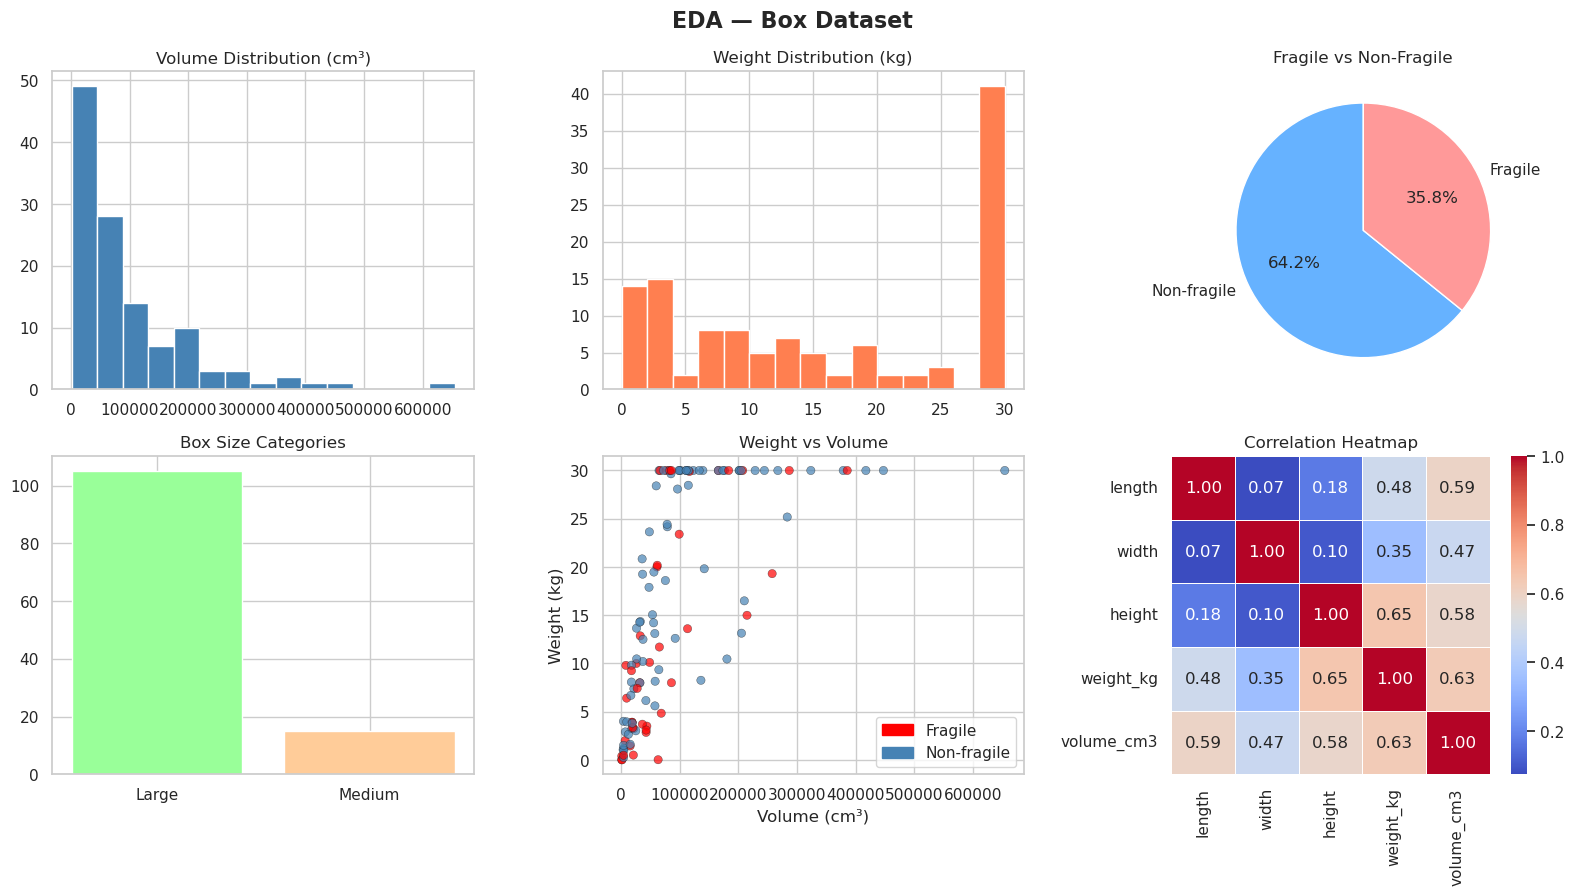

EDA plots saved ✅


In [10]:
DATA_PATH = Path("../data/boxes_120(generated+local).csv")

df = pd.read_csv(DATA_PATH)
print(f"Dataset loaded: {len(df)} rows")

# ── Cleaning ────────────────────────────────────────────────
df["fragile"] = df["fragile"].astype(bool)
for col in ["length", "width", "height", "weight_kg"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

before = len(df)
df.dropna(subset=["length", "width", "height", "weight_kg"], inplace=True)
df = df[
    (df["length"] > 0) & (df["width"] > 0) &
    (df["height"] > 0) & (df["weight_kg"] >= 0)
]
df.reset_index(drop=True, inplace=True)
print(f"Rows after cleaning: {len(df)}  (removed {before - len(df)})")

# ── Feature engineering ─────────────────────────────────────
df["volume_cm3"] = df["length"] * df["width"] * df["height"]
df["density"]    = df["weight_kg"] / df["volume_cm3"]

def size_cat(v):
    if v < 1_000:   return "Small"
    if v < 10_000:  return "Medium"
    return "Large"

df["size_category"] = df["volume_cm3"].apply(size_cat)

print("\n=== Summary ===")
print(df[["length","width","height","weight_kg","volume_cm3"]].describe().round(2))
print(f"\nFragile: {df['fragile'].sum()} / {len(df)}")
print(df["size_category"].value_counts())
df.head(5)


# ── EDA plots ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("EDA — Box Dataset", fontsize=16, fontweight="bold")

axes[0,0].hist(df["volume_cm3"], bins=15, color="steelblue", edgecolor="white")
axes[0,0].set_title("Volume Distribution (cm³)")

axes[0,1].hist(df["weight_kg"], bins=15, color="coral", edgecolor="white")
axes[0,1].set_title("Weight Distribution (kg)")

counts = df["fragile"].value_counts()
axes[0,2].pie(counts, labels=["Non-fragile","Fragile"], autopct="%1.1f%%",
              colors=["#66b2ff","#ff9999"], startangle=90)
axes[0,2].set_title("Fragile vs Non-Fragile")

sc = df["size_category"].value_counts()
axes[1,0].bar(sc.index, sc.values, color=["#99ff99","#ffcc99","#ff9999"])
axes[1,0].set_title("Box Size Categories")

col = df["fragile"].map({True:"red", False:"steelblue"})
axes[1,1].scatter(df["volume_cm3"], df["weight_kg"], c=col, alpha=0.7,
                  edgecolors="k", linewidths=0.3)
axes[1,1].set_title("Weight vs Volume")
axes[1,1].set_xlabel("Volume (cm³)")
axes[1,1].set_ylabel("Weight (kg)")
axes[1,1].legend(handles=[
    mpatches.Patch(color="red",      label="Fragile"),
    mpatches.Patch(color="steelblue",label="Non-fragile"),
])

corr = df[["length","width","height","weight_kg","volume_cm3"]].corr()
sns.heatmap(corr, ax=axes[1,2], annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, square=True)
axes[1,2].set_title("Correlation Heatmap")

plt.tight_layout()
plt.savefig("eda_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("EDA plots saved ✅")


In [11]:
CONTAINER_L = 520.0   # cm  (X)
CONTAINER_W = 210.0   # cm  (Z depth)
CONTAINER_H = 210.0   # cm  (Y height)

container = Container(length=CONTAINER_L, width=CONTAINER_W, height=CONTAINER_H)

boxes: List[Box] = [
    Box(
        id=int(row["id"]),
        length=float(row["length"]),
        width=float(row["width"]),
        height=float(row["height"]),
        weight_kg=float(row["weight_kg"]),
        fragile=bool(row["fragile"]),
    )
    for _, row in df.iterrows()
]

problem = CLOProblem(container=container, seq_boxes=boxes)
print(problem)



  Problem difficulty  : Medium
  Container           : (520.0, 210.0, 210.0)
  Number of boxes     : 120
  Total box volume    : 11,587,778.45 cm³
  Container volume    : 22,932,000.00 cm³
  Theoretical fill    : 50.5%


In [12]:
total_box_volume = df['volume_cm3'].sum()
container_volume = container.volume
utilization = (total_box_volume / container_volume) * 100

print(f'Container volume      : {container_volume:,.0f} cm³  ({container_volume/1e6:.3f} m³)')
print(f'Total box volume      : {total_box_volume:,.0f} cm³  ({total_box_volume/1e6:.3f} m³)')
print(f'Raw utilization       : {utilization:.2f}%')
print(f'\n→ We have {len(boxes)} boxes to pack.')
print(f'→ Theoretical max utilization (ignoring gaps): {utilization:.1f}%')
print(f'→ Target after optimization: ≥ 75–80%')

Container volume      : 22,932,000 cm³  (22.932 m³)
Total box volume      : 11,587,778 cm³  (11.588 m³)
Raw utilization       : 50.53%

→ We have 120 boxes to pack.
→ Theoretical max utilization (ignoring gaps): 50.5%
→ Target after optimization: ≥ 75–80%


In [13]:
#df.to_csv('boxes_preprocessed.csv', index=False)
DATA_DIR = Path("../data")
df.to_csv(DATA_DIR / 'boxes_preprocessed.csv', index=False)
print('Saved boxes_preprocessed.csv ✅')
print(f'Final dataset shape: {df.shape}')
df.head()

Saved boxes_preprocessed.csv ✅
Final dataset shape: (120, 9)


,id,length,width,height,weight_kg,fragile,volume_cm3,density,size_category
0,1,62.0,17.0,60.0,0.020,True,63240.0,3.162555e-07,Large
1,2,15.0,12.0,6.0,0.015,True,1080.0,1.388889e-05,Medium
2,3,31.0,25.0,9.0,2.000,True,6975.0,2.867384e-04,Medium
3,4,61.0,43.0,8.0,0.500,True,20984.0,2.382768e-05,Large
4,5,58.0,39.0,38.0,8.000,True,85956.0,9.307087e-05,Large


In [14]:
# helper : decode a sequence --> PackingResult
def decode_sequence(
    sequence: List[Box],
    container: Container,
    strategy: str = "bottom",
    algorithm_name: str = "Decoder",
) -> PackingResult:
    """
    Pack *sequence* of boxes greedily into *container*.
    Returns a PackingResult.
    """
    sm = SpaceManager(container)
    placed: List[PlacedBox] = []

    for box in sequence:
        space, dims = sm.find_placement(box, strategy=strategy)
        if space and dims:
            pb = sm.place_box(box, space, dims)
            if pb:
                placed.append(pb)

    return PackingResult(
        algorithm=algorithm_name,
        container=container,
        placed_boxes=placed,
        packed_volume=sm.packed_volume,
        execution_time_ms=0.0,   # caller sets this
    )


<div class="alert alert-block alert-warning">
<center>
    <h2>  The Algorithms</h2>
</center>
</div>

## Greedy Heuristic (Best-Fit Decreasing)

#### Sort boxes by volume (largest first). Place each box in the first available space that fits.

##### Greedy algorithms are a class of algorithms that make locally optimal choices at each step with the hope of finding a global optimum solution.  

- At every step of the algorithm, we make a choice that looks the best at the moment.  

>>>> Placing the biggest box first  

- To make the choice, we sometimes sort the array so that we can always get the next optimal choice quickly.  

>>>> Sorting the boxes depending on the volume from biggest to smallest

- After making a choice, we check for constraints (if there are any) and keep picking until we find the solution.  
Greedy algorithms do not always give the best solution.  

<div class="alert alert-block alert-info"> 
<b>We used a priority queue to get the next optimal item.</b>
</div>

In [15]:
class GreedyPacker:
    """
    Sort boxes by volume descending (max-heap) and place each one using
    the 'bottom' (gravity-aware) strategy.
    """

    def pack(self, problem: CLOProblem) -> PackingResult:
        t0 = time.time()

        # Build a max-heap keyed on -volume so the largest box pops first
        heap: List[Tuple[float, int, Box]] = [
            (-box.volume, box.id, box) for box in problem.seq_boxes
        ]
        heapq.heapify(heap)

        sm = SpaceManager(problem.container)
        placed: List[PlacedBox] = []

        while heap:
            _, _, box = heapq.heappop(heap)
            space, dims = sm.find_placement(box, strategy="bottom")
            if space and dims:
                pb = sm.place_box(box, space, dims)
                if pb:
                    placed.append(pb)

        return PackingResult(
            algorithm="Greedy Best-Fit Decreasing",
            container=problem.container,
            placed_boxes=placed,
            packed_volume=sm.packed_volume,
            execution_time_ms=(time.time() - t0) * 1000,
        )


## Genetic Algorithm (GA)
- Chromosome: A permutation (sequence) of boxes to pack.  
- Decoder (Heuristic): Take the sequence from the GA and place each box using a "Best Fit" logic.  
- Fitness: The total volume packed.

In [16]:
class GAPacker:
    """
    Genetic Algorithm for the 3D Container Loading Problem.

    Chromosome  : permutation (sequence) of boxes to pack
    Fitness     : total volume packed (decoded with greedy heuristic)
    Selection   : tournament
    Crossover   : Order Crossover (OX1)
    Mutation    : random swap
    Elitism     : top-k individuals survive unchanged
    """

    def __init__(
        self,
        pop_size:       int   = 50,
        generations:    int   = 100,
        crossover_prob: float = 0.85,
        mutation_prob:  float = 0.15,
        tournament_k:   int   = 5,
        elitism:        int   = 2,
        strategy:       str   = "bottom",
        seed:           Optional[int] = 42,
    ):
        self.pop_size       = pop_size
        self.generations    = generations
        self.crossover_prob = crossover_prob
        self.mutation_prob  = mutation_prob
        self.tournament_k   = tournament_k
        self.elitism        = elitism
        self.strategy       = strategy
        if seed is not None:
            random.seed(seed)

    # ── fitness ─────────────────────────────────────────────
    def _fitness(self, chromosome: List[Box], container: Container) -> float:
        sm = SpaceManager(container)
        for box in chromosome:
            space, dims = sm.find_placement(box, strategy=self.strategy)
            if space and dims:
                sm.place_box(box, space, dims)
        return sm.packed_volume

    # ── selection: tournament ────────────────────────────────
    def _tournament_select(
        self,
        population: List[List[Box]],
        fitnesses:  List[float],
    ) -> List[Box]:
        candidates = random.sample(range(len(population)), self.tournament_k)
        best_idx   = max(candidates, key=lambda i: fitnesses[i])
        return population[best_idx][:]

    # ── crossover: Order Crossover (OX1) ────────────────────
    @staticmethod
    def _ox1(parent_a: List[Box], parent_b: List[Box]) -> List[Box]:
        """
        OX1 preserves relative ordering from parent_b and a random
        segment from parent_a.
        """
        n = len(parent_a)
        i, j = sorted(random.sample(range(n), 2))

        segment   = parent_a[i:j+1]
        seg_ids   = {b.id for b in segment}

        child    = [None] * n
        child[i:j+1] = segment

        fill_pos = [(k % n) for k in range(j+1, j+1+n) if k % n not in range(i, j+1)]
        fill_vals = [b for b in parent_b if b.id not in seg_ids]

        for pos, val in zip(fill_pos, fill_vals):
            child[pos] = val

        return child

    # ── mutation: random swap ────────────────────────────────
    @staticmethod
    def _mutate(chromosome: List[Box]) -> List[Box]:
        mutant = chromosome[:]
        i, j = random.sample(range(len(mutant)), 2)
        mutant[i], mutant[j] = mutant[j], mutant[i]
        return mutant

    # ── main ────────────────────────────────────────────────
    def pack(self, problem: CLOProblem) -> PackingResult:
        t0 = time.time()
        container = problem.container
        boxes     = problem.seq_boxes

        # Initial population: random shuffles
        population = [random.sample(boxes, len(boxes))
                      for _ in range(self.pop_size)]

        best_chromosome = population[0][:]
        best_fitness    = 0.0
        history         = []   # (generation, best_util%)

        for gen in range(self.generations):

            # Evaluate fitness for every chromosome
            fitnesses = [self._fitness(chrom, container) for chrom in population]

            # Track best
            gen_best_idx = max(range(self.pop_size), key=lambda i: fitnesses[i])
            if fitnesses[gen_best_idx] > best_fitness:
                best_fitness    = fitnesses[gen_best_idx]
                best_chromosome = population[gen_best_idx][:]

            history.append((gen, best_fitness / container.volume * 100))

            # ── Build next generation ────────────────────────
            # 1. Elitism: keep top-k unchanged
            sorted_idx  = sorted(range(self.pop_size),
                                  key=lambda i: fitnesses[i], reverse=True)
            next_gen    = [population[i][:] for i in sorted_idx[:self.elitism]]

            # 2. Fill the rest with crossover + mutation
            while len(next_gen) < self.pop_size:
                p1 = self._tournament_select(population, fitnesses)
                p2 = self._tournament_select(population, fitnesses)

                if random.random() < self.crossover_prob:
                    child = self._ox1(p1, p2)
                else:
                    child = p1[:]  # no crossover → copy parent

                if random.random() < self.mutation_prob:
                    child = self._mutate(child)

                next_gen.append(child)

            population = next_gen

        # ── Final decode ─────────────────────────────────────
        result = decode_sequence(
            best_chromosome, container,
            strategy=self.strategy,
            algorithm_name="Genetic Algorithm",
        )
        result.execution_time_ms = (time.time() - t0) * 1000

        # Plot convergence
        gens, utils = zip(*history)
        plt.figure(figsize=(8, 4))
        plt.plot(gens, utils, color="steelblue", linewidth=2)
        plt.xlabel("Generation")
        plt.ylabel("Best Utilisation (%)")
        plt.title("GA — Convergence")
        plt.tight_layout()
        plt.savefig("ga_convergence.png", dpi=120)
        plt.show()

        return result

## Simulated Annealing

### What is Simulated Annealing?

Imagine you're trying to find the lowest point in a hilly landscape — blindfolded.  
A simple strategy: always step downhill. But this gets you **stuck in small valleys** (local optima).  

Simulated Annealing's strategy: **sometimes take a step uphill on purpose**, especially early on.  
As time goes on, you take fewer and fewer uphill steps until you only go downhill.  
This way you **escape local optima** and find a much better valley (global optimum).  

The name comes from **metallurgy**: when you heat metal and let it cool slowly,  
atoms settle into a strong, low-energy structure. Fast cooling = weak metal. Slow cooling = strong metal.  
We do the same with our solution.  

---
### How it works in our project:

1. Start with a random order (sequence) of boxes
2. Pack them into the container using a heuristic → measure how full it is (**fitness**)
3. **Perturb**: randomly swap two boxes in the sequence
4. Pack again → measure new fitness
5. If new is better → accept it
6. If new is worse → **maybe accept it anyway** (based on temperature)
7. Slowly lower the temperature → repeat thousands of times
8. Return the best solution found

In [17]:
class SAPacker:
    """
    Simulated Annealing over box permutations.

    Chromosome  : permutation (sequence) of boxes
    Perturbation: random swap of two boxes in the sequence
    Fitness     : total volume packed (higher = better)
    """

    def __init__(
        self,
        T_init:     float = 500.0,
        alpha:      float = 0.99,
        iterations: int   = 500,
        strategy:   str   = "bottom",
        seed:       Optional[int] = 42,
    ):
        self.T_init     = T_init
        self.alpha      = alpha
        self.iterations = iterations
        self.strategy   = strategy
        if seed is not None:
            random.seed(seed)

    # ── internal evaluator ──────────────────────────────────
    def _evaluate(self, seq: List[Box], container: Container) -> float:
        sm = SpaceManager(container)
        for box in seq:
            space, dims = sm.find_placement(box, strategy=self.strategy)
            if space and dims:
                sm.place_box(box, space, dims)
        return sm.packed_volume

    # ── perturbation: random swap ────────────────────────────
    @staticmethod
    def _swap(seq: List[Box]) -> List[Box]:
        new_seq = seq[:]
        i, j = random.sample(range(len(new_seq)), 2)
        new_seq[i], new_seq[j] = new_seq[j], new_seq[i]
        return new_seq

    # ── main ────────────────────────────────────────────────
    def pack(self, problem: CLOProblem) -> PackingResult:
        t0 = time.time()
        theoretical_max = problem.total_box_volume 

        current_seq = sorted(problem.seq_boxes, key=lambda b: b.volume, reverse=True)
        current_score = self._evaluate(current_seq, problem.container)

        best_seq = current_seq[:]
        best_score = current_score
        
        print(f"  Theoretical max: {theoretical_max/problem.container.volume*100:.1f}%")
        print(f"  Initial: {best_score/problem.container.volume*100:.1f}%")

        no_improvement_count = 0
        T = self.T_init
        history = []   # for convergence plot

        for iteration in range(self.iterations):
            if best_score >= theoretical_max * 0.995:
                print(f"  🎯 Reached {best_score/theoretical_max*100:.1f}% of max - stopping at iteration {iteration}")
                break
            
            # IMPROVEMENT 3: Stop if no improvement for 100 iterations
            if no_improvement_count > 100:
                print(f"  ⏹️ No improvement for {no_improvement_count} iterations - stopping")
                break
            new_seq   = self._swap(current_seq)
            new_score = self._evaluate(new_seq, problem.container)

            delta = new_score - current_score

            # Accept better, or worse with probability e^(delta/T)
            if delta > 0 or (T > 1e-10 and random.random() < math.exp(delta / T)):
                current_seq   = new_seq
                current_score = new_score
                no_improvement_count = 0
            else:
                no_improvement_count += 1

            if current_score > best_score:
                best_score = current_score
                best_seq   = current_seq[:]

            T *= self.alpha

            if iteration % 100 == 0:
                history.append((iteration, best_score))
                util = best_score / problem.container.volume * 100
                print(f"  Iter {iteration}: {util:.1f}%")

        # Final decode with best sequence
        result = decode_sequence(
            best_seq, problem.container,
            strategy=self.strategy,
            algorithm_name="Simulated Annealing",
        )
        result.execution_time_ms = (time.time() - t0) * 1000

        # Plot convergence
        if history:
            iters, scores = zip(*history)
            plt.figure(figsize=(8, 4))
            plt.plot(iters, [s / problem.container.volume * 100 for s in scores],
                     color="darkorange", linewidth=2)
            plt.xlabel("Iteration")
            plt.ylabel("Best Utilisation (%)")
            plt.title("SA — Convergence")
            plt.tight_layout()
            plt.savefig("sa_convergence.png", dpi=120)
            plt.show()

        return result

<div class="alert alert-block alert-warning">
<center>
    <h2> Validation Helper </h2>
</center>
</div>

In [18]:
def validate_result(result: PackingResult, verbose: bool = True) -> dict:
    """
    Validate a PackingResult for:
        1. No overlaps between placed boxes
        2. All boxes within container boundaries
        3. Gravity: every box rests on the floor or another box

    Returns a dict with keys 'no_overlap', 'in_bounds', 'no_floating'.
    """
    placed    = result.placed_boxes
    container = result.container

    # ── 1. Overlaps ──────────────────────────────────────────
    overlaps = []
    for i in range(len(placed)):
        for j in range(i + 1, len(placed)):
            if placed[i].overlaps(placed[j]):
                overlaps.append((placed[i].box.id, placed[j].box.id))

    no_overlap = len(overlaps) == 0

    # ── 2. Boundaries ───────────────────────────────────────
    oob = [p for p in placed if not p.is_within(container)]
    in_bounds = len(oob) == 0

    # ── 3. Gravity (no floating boxes) ──────────────────────
    floating = []
    for p in placed:
        if p.y == 0:
            continue  # on the floor — OK
        supported = False
        for other in placed:
            if other is p:
                continue
            # other must reach exactly to the bottom face of p
            if abs((other.y + other.h) - p.y) < 1e-6:
                # horizontal overlap in X and Z
                x_overlap = (max(p.x, other.x) <
                             min(p.x + p.l, other.x + other.l))
                z_overlap = (max(p.z, other.z) <
                             min(p.z + p.w, other.z + other.w))
                if x_overlap and z_overlap:
                    supported = True
                    break
        if not supported:
            floating.append(p.box.id)

    no_floating = len(floating) == 0

    if verbose:
        print("=" * 60)
        print("  VALIDATION REPORT")
        print("=" * 60)
        print(f"  No overlaps    : {'✅ PASS' if no_overlap else f'❌ FAIL  ({len(overlaps)} pairs)'}")
        if not no_overlap:
            for a, b in overlaps[:5]:
                print(f"                   ↳ Box {a} ↔ Box {b}")
            if len(overlaps) > 5:
                print(f"                   ↳ … and {len(overlaps)-5} more")

        print(f"  In bounds      : {'✅ PASS' if in_bounds else f'❌ FAIL  ({len(oob)} boxes)'}")
        if not in_bounds:
            for p in oob[:5]:
                print(f"                   ↳ Box {p.box.id}")

        print(f"  No floating    : {'✅ PASS' if no_floating else f'⚠️  {len(floating)} floating'}")
        if not no_floating:
            print(f"                   ↳ IDs: {floating[:10]}")
        print("=" * 60)

    return {
        "no_overlap":  no_overlap,
        "in_bounds":   in_bounds,
        "no_floating": no_floating,
        "valid":       no_overlap and in_bounds,
    }


<div class="alert alert-block alert-warning">
<center>
    <h2> 3D-Visualisation </h2>
</center>
</div>

In [19]:
def visualize_packing(result: PackingResult, title: str = "Container Packing",
                      save_path: Optional[str] = None):
    """
    3D matplotlib render of the packed container.
    Each box is drawn as a transparent coloured cuboid.
    Fragile boxes are shown in red, normal in blue.
    """

    def cuboid_faces(x, y, z, l, h, w):
        """Return the 6 faces of a cuboid as lists of vertices."""
        return [
            # bottom
            [[x,y,z],[x+l,y,z],[x+l,y,z+w],[x,y,z+w]],
            # top
            [[x,y+h,z],[x+l,y+h,z],[x+l,y+h,z+w],[x,y+h,z+w]],
            # front
            [[x,y,z],[x+l,y,z],[x+l,y+h,z],[x,y+h,z]],
            # back
            [[x,y,z+w],[x+l,y,z+w],[x+l,y+h,z+w],[x,y+h,z+w]],
            # left
            [[x,y,z],[x,y,z+w],[x,y+h,z+w],[x,y+h,z]],
            # right
            [[x+l,y,z],[x+l,y,z+w],[x+l,y+h,z+w],[x+l,y+h,z]],
        ]

    fig = plt.figure(figsize=(14, 8))
    ax  = fig.add_subplot(111, projection="3d")

    c = result.container

    # Draw container outline
    for x0, x1 in [(0, c.length)]:
        for y0, y1 in [(0, c.height)]:
            for z0, z1 in [(0, c.width)]:
                for xs, ys, zs in [
                    ([x0,x1],[y0,y0],[z0,z0]), ([x0,x1],[y1,y1],[z0,z0]),
                    ([x0,x1],[y0,y0],[z1,z1]), ([x0,x1],[y1,y1],[z1,z1]),
                    ([x0,x0],[y0,y1],[z0,z0]), ([x1,x1],[y0,y1],[z0,z0]),
                    ([x0,x0],[y0,y1],[z1,z1]), ([x1,x1],[y0,y1],[z1,z1]),
                    ([x0,x0],[y0,y0],[z0,z1]), ([x1,x1],[y0,y0],[z0,z1]),
                    ([x0,x0],[y1,y1],[z0,z1]), ([x1,x1],[y1,y1],[z0,z1]),
                ]:
                    ax.plot(xs, ys, zs, color="black", linewidth=0.8, alpha=0.5)

    # Draw placed boxes
    cmap_normal  = plt.cm.Blues
    cmap_fragile = plt.cm.Reds
    n = max(len(result.placed_boxes), 1)

    for idx, p in enumerate(result.placed_boxes):
        faces = cuboid_faces(p.x, p.y, p.z, p.l, p.h, p.w)
        shade = 0.35 + 0.55 * (idx / n)
        color = cmap_fragile(shade) if p.box.fragile else cmap_normal(shade)
        poly  = Poly3DCollection(faces, alpha=0.55, linewidths=0.3,
                                  edgecolors="grey")
        poly.set_facecolor(color)
        ax.add_collection3d(poly)

    ax.set_xlim(0, c.length)
    ax.set_ylim(0, c.height)
    ax.set_zlim(0, c.width)
    ax.set_xlabel("Length (X)")
    ax.set_ylabel("Height (Y)")
    ax.set_zlabel("Depth  (Z)")

    ax.set_title(
        f"{title}\n"
        f"Boxes: {len(result.placed_boxes)}  |  "
        f"Utilisation: {result.utilization():.1f}%  |  "
        f"Time: {result.execution_time_ms:.0f} ms",
        fontsize=11,
    )

    blue_patch = mpatches.Patch(color=cmap_normal(0.6),  label="Normal box")
    red_patch  = mpatches.Patch(color=cmap_fragile(0.6), label="Fragile box")
    ax.legend(handles=[blue_patch, red_patch], loc="upper left")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"3D render saved to '{save_path}'")
    plt.show()


<div class="alert alert-block alert-warning">
<center>
    <h2> Run all three algorithms + comparison </h2>
</center>
</div>

In [20]:
print("=" * 70)
print("  RUNNING ALL THREE ALGORITHMS")
print("=" * 70)

# ── Greedy ──────────────────────────────────────────────────
print("\n[1/3] Greedy Best-Fit Decreasing …")
greedy_result = GreedyPacker().pack(problem)
print(greedy_result)

# ── SA ──────────────────────────────────────────────────────
print("\n[2/3] Simulated Annealing …")
sa_result = SAPacker(T_init=5_000, alpha=0.995, iterations=3_000).pack(problem)
print(sa_result)

# ── GA ──────────────────────────────────────────────────────
print("\n[3/3] Genetic Algorithm …")
ga_result = GAPacker(
    pop_size=40, generations=80,
    crossover_prob=0.85, mutation_prob=0.15,
).pack(problem)
print(ga_result)


  RUNNING ALL THREE ALGORITHMS

[1/3] Greedy Best-Fit Decreasing …
PackingResult(algorithm='Greedy Best-Fit Decreasing', utilization=50.53%, boxes=120, time=221.7ms)

[2/3] Simulated Annealing …
  Theoretical max: 50.5%
  Initial: 50.5%
  🎯 Reached 100.0% of max - stopping at iteration 0
PackingResult(algorithm='Simulated Annealing', utilization=50.53%, boxes=120, time=393.3ms)

[3/3] Genetic Algorithm …


KeyboardInterrupt: 

<h2>Validation for all results</h2>

In [ ]:
for label, res in [
    ("Greedy",              greedy_result),
    ("Simulated Annealing", sa_result),
    ("Genetic Algorithm",   ga_result),
]:
    print(f"\n── Validating: {label} ──")
    validate_result(res, verbose=True)


<div class="alert alert-block alert-warning">
<center>
    <h2>  Comparative Evaluation </h2>
</center>
</div>


In [ ]:
algorithms  = ["Greedy BFD", "Simulated\nAnnealing", "Genetic\nAlgorithm"]
results_lst = [greedy_result, sa_result, ga_result]

utils = [r.utilization() for r in results_lst]
times = [r.execution_time_ms for r in results_lst]
boxes_placed = [len(r.placed_boxes) for r in results_lst]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Comparative Evaluation — 3 Algorithms", fontsize=14, fontweight="bold")

colors = ["#4C72B0", "#DD8452", "#55A868"]

# Volume utilisation
bars0 = axes[0].bar(algorithms, utils, color=colors, edgecolor="k", linewidth=0.8)
axes[0].axhline(75, color="red", linestyle="--", linewidth=1.2, label="Target 75%")
axes[0].set_title("Volume Utilisation (%)")
axes[0].set_ylim(0, 100)
axes[0].legend()
for bar, val in zip(bars0, utils):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 1,
                 f"{val:.1f}%", ha="center", va="bottom", fontsize=10)

# Execution time
bars1 = axes[1].bar(algorithms, times, color=colors, edgecolor="k", linewidth=0.8)
axes[1].set_title("Execution Time (ms)")
axes[1].set_ylabel("ms")
for bar, val in zip(bars1, times):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 1,
                 f"{val:.0f}", ha="center", va="bottom", fontsize=10)

# Boxes placed
bars2 = axes[2].bar(algorithms, boxes_placed, color=colors,
                     edgecolor="k", linewidth=0.8)
axes[2].set_title(f"Boxes Placed (out of {len(boxes)})")
axes[2].axhline(len(boxes), color="grey", linestyle=":", linewidth=1.2)
for bar, val in zip(bars2, boxes_placed):
    axes[2].text(bar.get_x() + bar.get_width()/2, val + 0.2,
                 str(val), ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.savefig("comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Comparison plot saved ✅")

# ── Summary table ────────────────────────────────────────────
print("\n" + "=" * 70)
print(f"{'Algorithm':<28} {'Boxes':>6} {'Vol (cm³)':>14} "
      f"{'Util%':>7} {'Time(ms)':>10}")
print("-" * 70)
for name, res in zip(algorithms, results_lst):
    print(f"{name.replace(chr(10),' '):<28} "
          f"{len(res.placed_boxes):>6} "
          f"{res.packed_volume:>14,.0f} "
          f"{res.utilization():>7.2f} "
          f"{res.execution_time_ms:>10.1f}")
print("=" * 70)


NameError: name 'sa_result' is not defined